# 1. General Overview

Load dataset, ensure that it works also from another computer

In [1]:
# If any import fails, run e.g.:
# %pip install pandas plotly

from pathlib import Path
import pandas as pd
import numpy as np
import plotly.express as px

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


In [2]:
# Works whether you run the notebook from repo root or /notebook/
cwd = Path.cwd()
root = cwd if (cwd / "data").exists() else cwd.parent

candidates = [
    root / "data" / "mind@work" / "mental_health_dataset" / "Cleaned_remote_work.csv",
    root / "data" / "mind@work" / "mental heath dataset" / "Cleaned_remote_work.csv",  # legacy typo
]

data_file = next((p for p in candidates if p.exists()), None)
assert data_file is not None, f"Dataset not found. Checked:\n- " + "\n- ".join(map(str, candidates))
data_file


PosixPath('/Users/huongle/Documents/GitHub/Mind_At_Work_Website/data/mind@work/mental_health_dataset/Cleaned_remote_work.csv')

In [3]:
df = pd.read_csv(data_file)
print(f"rows: {len(df):,} | cols: {df.shape[1]}")
df.head()

rows: 5,000 | cols: 19


,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,No Activity,Poor,North America
3,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,No Activity,Poor,Europe
4,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,No Condition,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [4]:
print("Dataset shape:", df.shape)
df.info()
df.describe()

Dataset shape: (5000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                5000 non-null   int64 
 1   Gender                             5000 non-null   object
 2   Job_Role                           5000 non-null   object
 3   Industry                           5000 non-null   object
 4   Years_of_Experience                5000 non-null   int64 
 5   Work_Location                      5000 non-null   object
 6   Hours_Worked_Per_Week              5000 non-null   int64 
 7   Number_of_Virtual_Meetings         5000 non-null   int64 
 8   Work_Life_Balance_Rating           5000 non-null   int64 
 9   Stress_Level                       5000 non-null   object
 10  Mental_Health_Condition            5000 non-null   object
 11  Access_to_Mental_Health_Resources  5000 non

,Age,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Social_Isolation_Rating,Company_Support_for_Remote_Work
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.995000,17.810200,39.614600,7.559000,2.984200,2.993800,3.007800
std,11.296021,10.020412,11.860194,4.636121,1.410513,1.394615,1.399046
min,22.000000,1.000000,20.000000,0.000000,1.000000,1.000000,1.000000
25%,31.000000,9.000000,29.000000,4.000000,2.000000,2.000000,2.000000
50%,41.000000,18.000000,40.000000,8.000000,3.000000,3.000000,3.000000
75%,51.000000,26.000000,50.000000,12.000000,4.000000,4.000000,4.000000
max,60.000000,35.000000,60.000000,15.000000,5.000000,5.000000,5.000000


For descriptive analysis (EDA): i will leave them as object. Pandas .value_counts() and Seaborn plots work fine. But later for modelling like classification, they should have categorical as datatype.

In [5]:

df["Mental_Health_Condition"].replace(r"^\s*$", np.nan, regex=True, inplace=True)
df["Physical_Activity"].replace(r"^\s*$", np.nan, regex=True, inplace=True)

df["Physical_Activity"].fillna("No Activity", inplace=True)
df["Mental_Health_Condition"].fillna("No Condition", inplace=True)

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_8722/3041038079.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Mental_Health_Condition"].replace(r"^\s*$", np.nan, regex=True, inplace=True)
/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_8722/3041038079.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on w

In [6]:

df = pd.read_csv(data_file)
df.head()

,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,No Activity,Poor,North America
3,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,No Activity,Poor,Europe
4,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,No Condition,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


# 2. Checking any reationships between variables.

### 2.1. Realtionships between categorical variables

In [7]:
def load_cleaned_remote_work():
    root = Path.cwd()
    if not (root / "data").exists():
        root = root.parent  # if running from /notebook

    candidates = [
        root / "data/mind@work/mental_health_dataset/Cleaned_remote_work.csv",
        root / "data/mind@work/mental heath dataset/Cleaned_remote_work.csv",  # legacy folder name with a space
    ]
    for p in candidates:
        if p.exists():
            print(f"Loading: {p}")
            return pd.read_csv(p)

    # fallback: search anywhere under the repo
    hits = list(root.rglob("Cleaned_remote_work.csv"))
    if hits:
        print(f"Loading (found by search): {hits[0]}")
        return pd.read_csv(hits[0])

    raise FileNotFoundError(
        f"Could not find Cleaned_remote_work.csv.\nTried:\n- " +
        "\n- ".join(map(str, candidates)) +
        "\nAnd a recursive search under: " + str(root)
    )

# ---- restore df as a DataFrame
df = load_cleaned_remote_work()
print(type(df), df.shape)   # should show <class 'pandas.core.frame.DataFrame'>

Loading: /Users/huongle/Documents/GitHub/Mind_At_Work_Website/data/mind@work/mental_health_dataset/Cleaned_remote_work.csv
<class 'pandas.core.frame.DataFrame'> (5000, 19)


In [8]:
from itertools import combinations
from scipy.stats import chi2_contingency

def scan_categorical_relationships(df_in, alpha=0.05):
    if not isinstance(df_in, pd.DataFrame):
        raise TypeError(f"Expected a pandas DataFrame, got {type(df_in)}. "
                        "Did you overwrite `df` earlier?")
    df = df_in.copy()

    # pick categorical-like columns
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    results = []
    for col1, col2 in combinations(cat_cols, 2):
        ct = pd.crosstab(df[col1].fillna("Missing"), df[col2].fillna("Missing"))
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            chi2, p, dof, _ = chi2_contingency(ct)
            results.append({
                "Var1": col1, "Var2": col2,
                "Chi2": chi2, "dof": dof, "p_value": p,
                "Significant": p < alpha
            })

    res = pd.DataFrame(results)
    return res.sort_values("p_value") if not res.empty else res


In [9]:
chi_results = scan_categorical_relationships(df)
chi_results.head(10)             # top 10 by p-value
sig = chi_results[chi_results.p_value < 0.05]
sig.head(10)


,Var1,Var2,Chi2,dof,p_value,Significant
14,Job_Role,Mental_Health_Condition,51.281227,18,0.000048,True
34,Work_Location,Satisfaction_with_Remote_Work,14.488583,4,0.005888,True
39,Stress_Level,Access_to_Mental_Health_Resources,7.224236,2,0.026995,True
8,Gender,Physical_Activity,13.629166,6,0.034064,True
58,Productivity_Change,Sleep_Quality,9.962953,4,0.041056,True
51,Access_to_Mental_Health_Resources,Productivity_Change,6.272912,2,0.043436,True


Since we have some realationshiop here. I would draw a heatmap

In [10]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [11]:

import seaborn as sns
import matplotlib.pyplot as plt

# ---- 1) Scanner with Cramér's V (+ optional FDR) ----
def scan_categorical_relationships(
    df_in, alpha=0.05, fdr=True, include=["object","category","bool"]
):
    if not isinstance(df_in, pd.DataFrame):
        raise TypeError("Expected a pandas DataFrame.")
    df = df_in.copy()
    df.columns = df.columns.str.strip()

    cat_cols = df.select_dtypes(include=include).columns.tolist()
    results = []

    for col1, col2 in combinations(cat_cols, 2):
        ct = pd.crosstab(df[col1].fillna("Missing"), df[col2].fillna("Missing"))
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            chi2, p, dof, _ = chi2_contingency(ct)
            n = ct.to_numpy().sum()
            r, c = ct.shape
            k = max(min(r - 1, c - 1), 1)
            cramers_v = np.sqrt((chi2 / n) / k)

            results.append({
                "Var1": col1, "Var2": col2,
                "Chi2": chi2, "dof": dof, "p_value": p,
                "n": n, "CramersV": cramers_v
            })

    res = pd.DataFrame(results)
    if res.empty:
        return res

    # Optional Benjamini–Hochberg FDR
    if fdr:
        res = res.sort_values("p_value").reset_index(drop=True)
        m = len(res)
        ranks = np.arange(1, m+1)
        res["q_value"] = (res["p_value"] * m / ranks).cummin().clip(upper=1.0)
        res["Significant"] = res["q_value"] < alpha
    else:
        res["Significant"] = res["p_value"] < alpha

    return res.sort_values(["Significant","p_value"], ascending=[False, True])

# ---- 2) Heatmap of association strength (-log10 p) or Cramér’s V ----
def plot_assoc_heatmap(res, value="CramersV"):
    """
    value: "CramersV" or "p_value" (will show -log10 p if chosen)
    """
    if res.empty:
        print("No categorical relationships to plot.")
        return

    vars_ = sorted(set(res["Var1"]).union(res["Var2"]))
    M = pd.DataFrame(np.nan, index=vars_, columns=vars_)

    for _, r in res.iterrows():
        a, b = r["Var1"], r["Var2"]
        val = r[value]
        if value == "p_value":
            val = -np.log10(max(r["p_value"], 1e-300))  # avoid log(0)
        M.loc[a, b] = val
        M.loc[b, a] = val
        M.loc[a, a] = M.loc[a, a] if pd.notna(M.loc[a, a]) else (0 if value=="CramersV" else 0)

    mask = np.triu(np.ones_like(M, dtype=bool))  # plot lower triangle
    plt.figure(figsize=(1.1*len(vars_), 1.0*len(vars_)))
    ax = sns.heatmap(
        M, mask=mask, cmap="viridis", square=True, linewidths=0.5,
        cbar_kws={"label": ("Cramér's V" if value=="CramersV" else "-log10(p)")}
    )
    ax.set_title("Categorical Association Map" + ("" if value=="CramersV" else " (significance)"))
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# ---- 3) Network graph of significant links (weight = Cramér’s V) ----
def plot_assoc_network(res, min_v=0.1):
    """
    Draw edges for Significant pairs; edge width ~ Cramér’s V.
    min_v filters very weak links.
    """
    if res.empty:
        print("No categorical relationships to plot.")
        return

    import networkx as nx

    sig = res[res["Significant"]].copy()
    if sig.empty:
        print("No significant relationships at chosen threshold.")
        return

    sig = sig[sig["CramersV"] >= min_v]
    if sig.empty:
        print(f"No edges with Cramér's V ≥ {min_v}.")
        return

    G = nx.Graph()
    for v in sorted(set(sig["Var1"]).union(sig["Var2"])):
        G.add_node(v)

    for _, r in sig.iterrows():
        G.add_edge(r["Var1"], r["Var2"], weight=r["CramersV"])

    pos = nx.spring_layout(G, seed=7, k=0.6)
    weights = [2 + 6*G[u][v]["weight"] for u,v in G.edges()]  # scale widths

    plt.figure(figsize=(10, 8))
    nx.draw_networkx_nodes(G, pos, node_size=1200, alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=10)
    nx.draw_networkx_edges(G, pos, width=weights, alpha=0.7)
    plt.title("Significant Categorical Relationships (edge width = Cramér’s V)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [12]:
res = scan_categorical_relationships(df, alpha=0.05, fdr=True)

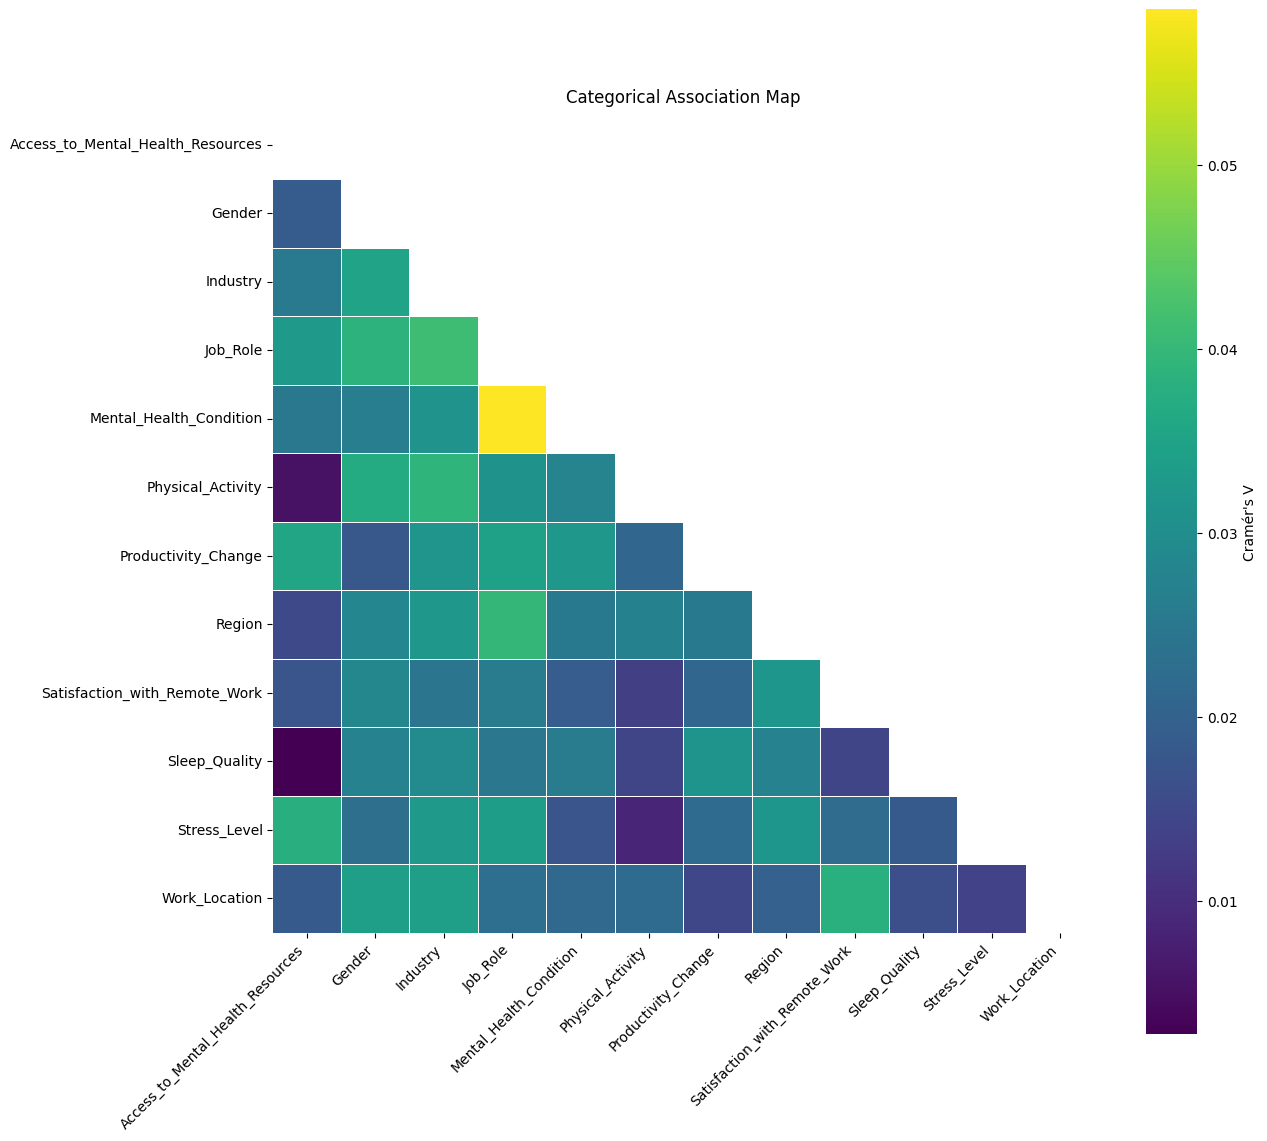

In [13]:
plot_assoc_heatmap(res, value="CramersV")

In [14]:
def plot_pvalue_heatmap(res):
    """
    Draw a simple heatmap of p-values from scan_categorical_relationships().
    Darker color = smaller p-value (stronger relationship).
    """
    if res.empty:
        print("No categorical relationships to plot.")
        return

    # Create symmetric matrix of p-values
    vars_ = sorted(set(res["Var1"]).union(res["Var2"]))
    M = pd.DataFrame(1.0, index=vars_, columns=vars_)  # start with 1.0 (non-significant)

    for _, r in res.iterrows():
        a, b, p = r["Var1"], r["Var2"], r["p_value"]
        M.loc[a, b] = M.loc[b, a] = p

    # Plot
    plt.figure(figsize=(1.2*len(vars_), 1.0*len(vars_)))
    mask = np.triu(np.ones_like(M, dtype=bool))
    ax = sns.heatmap(
        M, mask=mask, cmap="viridis_r",  # lighter = less significant, darker = more
        annot=True, fmt=".3f", square=True, linewidths=0.5,
        cbar_kws={"label": "p-value"}
    )
    ax.set_title("Categorical Relationship Significance (p-values)")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

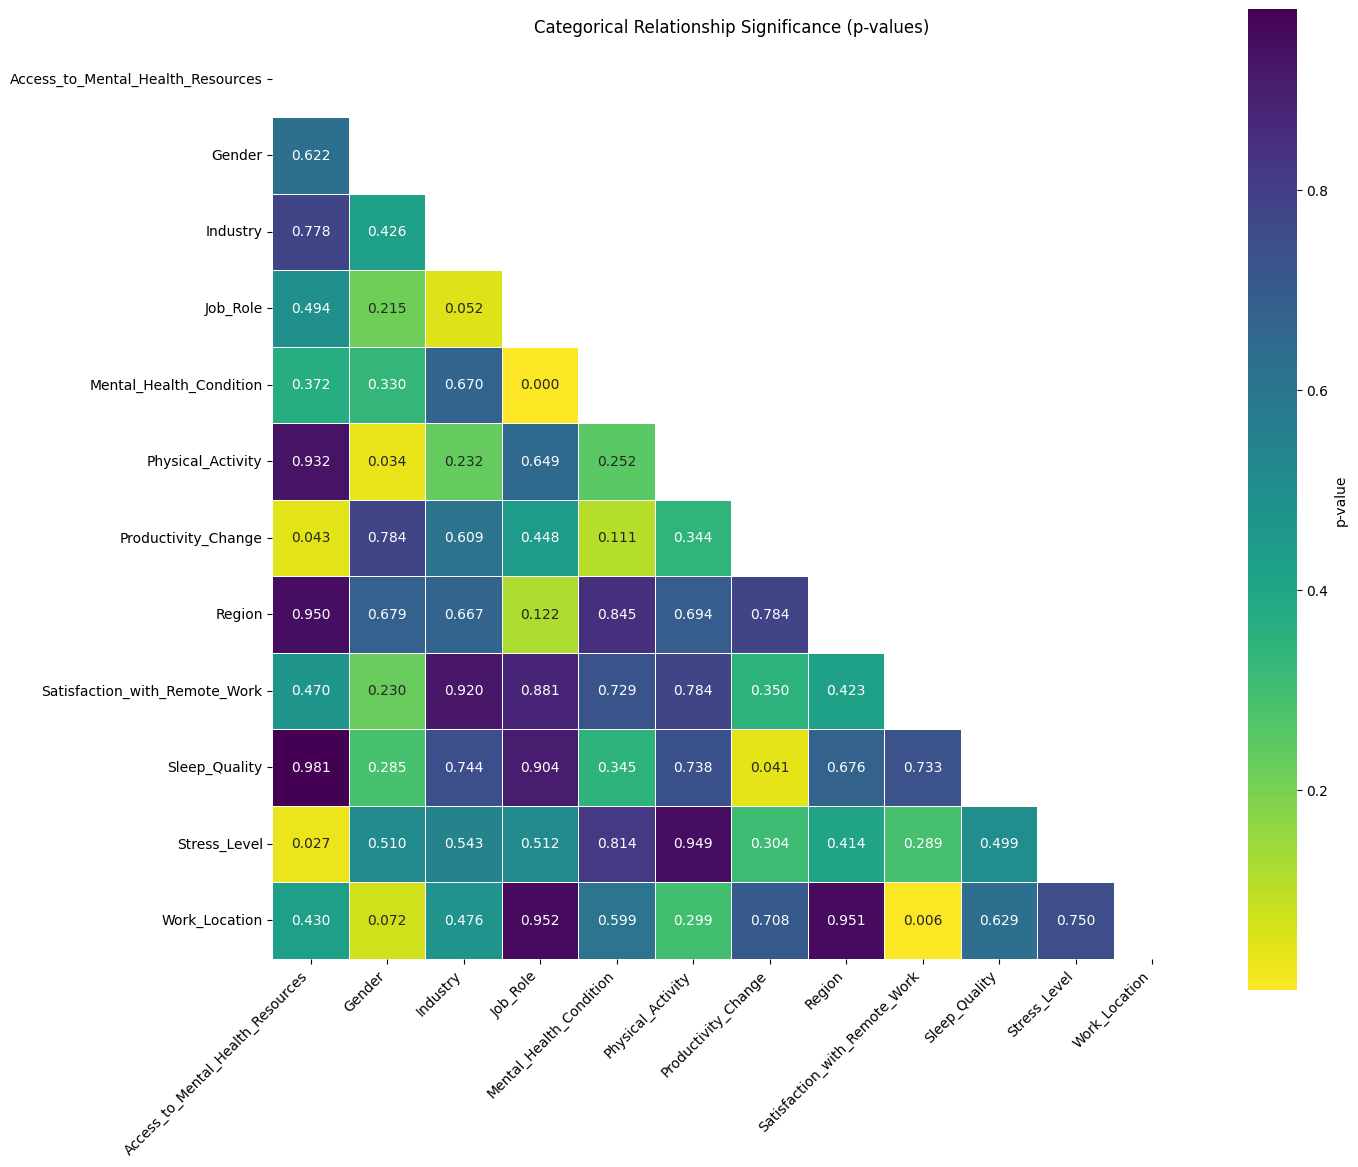

In [15]:
res = scan_categorical_relationships(df, alpha=0.05)
plot_pvalue_heatmap(res)

Yellow	0.00 – 0.05	Statistically significant relationship
Green	~0.05 – 0.3	Weak or borderline significance
More pupre	> 0.3 – 1.0	No significant relationship

- Mental health condition and job role having realtionship
- Stress level and acess to mental health reseouce
- sastifaction and work location


#### Q1. Sastifaction and work location

In [16]:
pd.crosstab(df["Work_Location"], df["Satisfaction_with_Remote_Work"], normalize="index") * 100


Satisfaction_with_Remote_Work,Neutral,Satisfied,Unsatisfied
Work_Location,,,
Hybrid,32.686477,34.202547,33.110976
Onsite,30.910202,36.163714,32.926084
Remote,35.180863,30.280047,34.539090


Look sysnthetics distribution. Lets try to plot them in bar plot

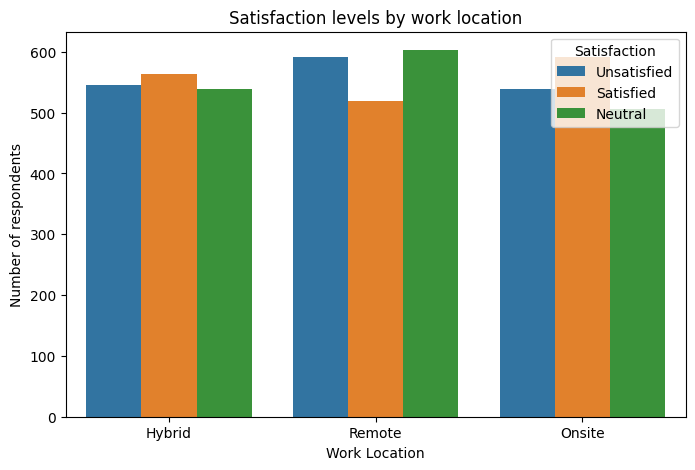

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Work_Location", hue="Satisfaction_with_Remote_Work")
plt.title("Satisfaction levels by work location")
plt.xlabel("Work Location")
plt.ylabel("Number of respondents")
plt.legend(title="Satisfaction")
plt.show()


They doesn't look differents between sastifaction in differents location

in percentage

<Axes: xlabel='Work_Location', ylabel='Percent'>

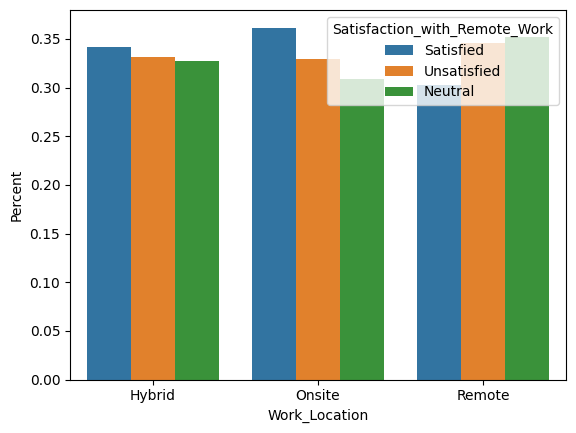

In [18]:
(df.groupby("Work_Location")["Satisfaction_with_Remote_Work"]
   .value_counts(normalize=True)
   .rename("Percent")
   .reset_index()
   .pipe(lambda d: sns.barplot(data=d, x="Work_Location",
                               y="Percent", hue="Satisfaction_with_Remote_Work")))

Onsite workers looks more sastified with their job, remote workers are less happy

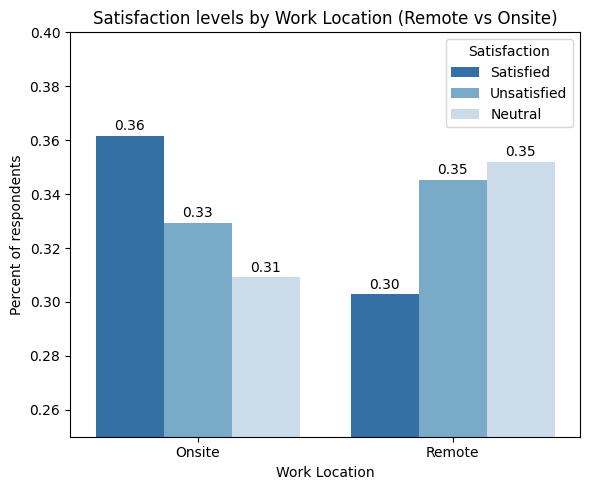

In [19]:
# --- Filter only remote and onsite
subset = df[df["Work_Location"].isin(["Remote", "Onsite"])].copy()

# --- Calculate percentage by location
share = (
    subset.groupby("Work_Location")["Satisfaction_with_Remote_Work"]
          .value_counts(normalize=True)
          .rename("Percent")
          .reset_index()
)

# --- Plot (only Remote + Onsite)
plt.figure(figsize=(6,5))
sns.barplot(
    data=share,
    x="Work_Location",
    y="Percent",
    hue="Satisfaction_with_Remote_Work",
    palette="Blues_r"   # reversed blues palette for contrast
)

plt.title("Satisfaction levels by Work Location (Remote vs Onsite)")
plt.xlabel("Work Location")
plt.ylabel("Percent of respondents")

# --- Make differences clearer (zoom in)
plt.ylim(0.25, 0.40)   # focus on 25%–40% range to enlarge differences

# --- Add labels on bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt="%.2f", label_type="edge", fontsize=10, padding=2)

plt.legend(title="Satisfaction")
plt.tight_layout()
plt.show()

I am cheating by zoom in the part 0.25 - 0.4%. Onsite workers show the highest share of “Satisfied”. Remote workers show fewer “Satisfied”

Try with combination features: sastify = sastified+neutral, and unsastified

Contingency Table:
Satisfaction_Simple  Satisfied  Unsatisfied
Work_Location                              
Onsite                    1098          539
Remote                    1122          592

Chi-square = 0.903, dof = 1, p-value = 0.3418


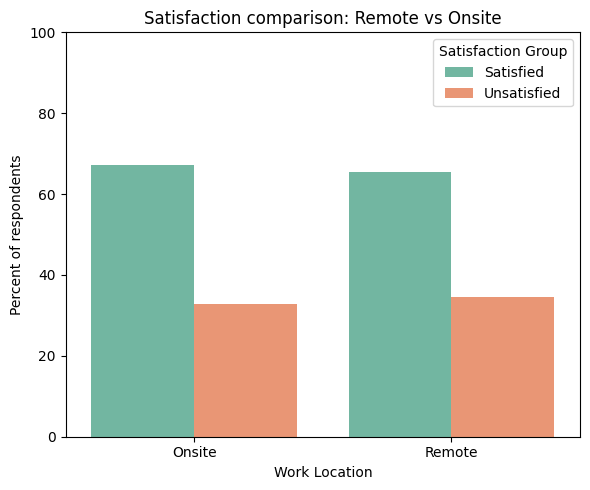

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# --- 1️⃣ Filter only remote and onsite workers
subset = df[df["Work_Location"].isin(["Remote", "Onsite"])].copy()

# --- 2️⃣ Combine satisfaction levels
subset["Satisfaction_Simple"] = subset["Satisfaction_with_Remote_Work"].replace({
    "Neutral": "Satisfied",
    "Satisfied": "Satisfied",
    "Unsatisfied": "Unsatisfied"
})

# --- 3️⃣ Build contingency table
ct = pd.crosstab(subset["Work_Location"], subset["Satisfaction_Simple"])
print("Contingency Table:")
print(ct)

# --- 4️⃣ Chi-square test
chi2, p, dof, exp = chi2_contingency(ct)
print(f"\nChi-square = {chi2:.3f}, dof = {dof}, p-value = {p:.4f}")

# --- 5️⃣ Plot proportions
share = (ct.div(ct.sum(axis=1), axis=0) * 100).reset_index().melt(
    id_vars="Work_Location", var_name="Satisfaction_Simple", value_name="Percent"
)

plt.figure(figsize=(6,5))
sns.barplot(data=share, x="Work_Location", y="Percent", hue="Satisfaction_Simple", palette="Set2")
plt.title("Satisfaction comparison: Remote vs Onsite")
plt.ylabel("Percent of respondents")
plt.xlabel("Work Location")
plt.ylim(0, 100)
plt.legend(title="Satisfaction Group")
plt.tight_layout()
plt.show()


This doesn't show patterns

#### Q2. Stress level and Access to mental health source

Contingency Table:
Stress_Level                       High  Low  Medium
Access_to_Mental_Health_Resources                   
No                                  817  870     866
Yes                                 869  775     803

Chi-square = 7.224, dof = 2, p-value = 0.0270


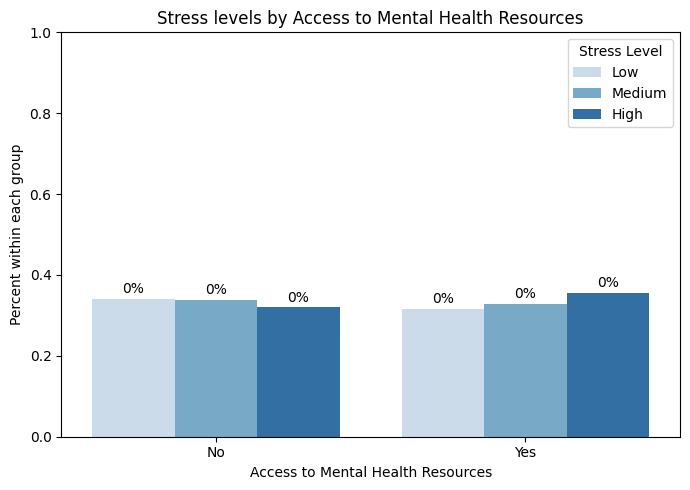

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# --- Crosstab for chi-square test ---
ct = pd.crosstab(df["Access_to_Mental_Health_Resources"], df["Stress_Level"])
print("Contingency Table:")
print(ct)

chi2, p, dof, expected = chi2_contingency(ct)
print(f"\nChi-square = {chi2:.3f}, dof = {dof}, p-value = {p:.4f}")

# --- Correct proportions (normalize by each Access group)
share = (
    df.groupby("Access_to_Mental_Health_Resources")["Stress_Level"]
      .value_counts(normalize=True)
      .rename("Percent")
      .reset_index()
)

# --- Plot percentages
plt.figure(figsize=(7,5))
ax = sns.barplot(
    data=share,
    x="Access_to_Mental_Health_Resources",
    y="Percent",
    hue="Stress_Level",
    palette="Blues"
)

plt.title("Stress levels by Access to Mental Health Resources")
plt.xlabel("Access to Mental Health Resources")
plt.ylabel("Percent within each group")
plt.ylim(0, 1)

# ✅ Correct line — properly closed quotation mark
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f%%", label_type="edge", fontsize=10, padding=2)

plt.legend(title="Stress Level")
plt.tight_layout()
plt.show()


Contingency Table:
 Stress_Level                       High  Low
Access_to_Mental_Health_Resources           
No                                  817  870
Yes                                 869  775

Chi-square = 6.360, dof = 1, p-value = 0.0117


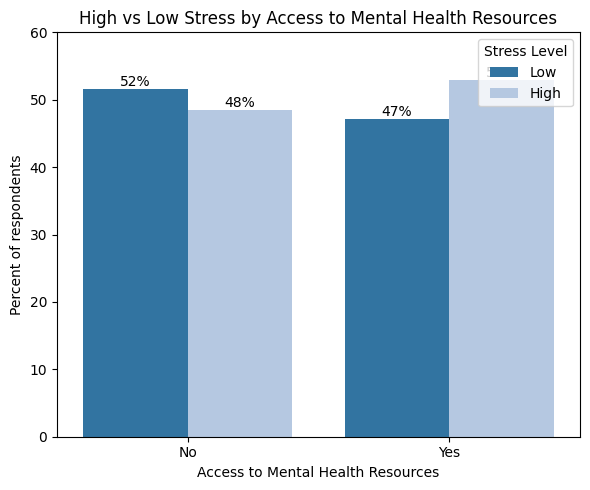

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact

# --- Filter only High & Low stress ---
subset = df[df["Stress_Level"].isin(["High", "Low"])].copy()

# --- 2×2 table
ct = pd.crosstab(subset["Access_to_Mental_Health_Resources"], subset["Stress_Level"])
chi2, p, dof, expected = chi2_contingency(ct)
print("Contingency Table:\n", ct)
print(f"\nChi-square = {chi2:.3f}, dof = {dof}, p-value = {p:.4f}")

# --- Calculate % within each Access group
share = (
    subset.groupby("Access_to_Mental_Health_Resources")["Stress_Level"]
          .value_counts(normalize=True)
          .rename("Percent")
          .reset_index()
)
share["Percent"] *= 100

# --- Simple grouped barplot
plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=share,
    x="Access_to_Mental_Health_Resources",
    y="Percent",
    hue="Stress_Level",
    palette=["#1f77b4", "#aec7e8"]  # deep + light blue
)

plt.title("High vs Low Stress by Access to Mental Health Resources")
plt.xlabel("Access to Mental Health Resources")
plt.ylabel("Percent of respondents")
plt.ylim(0, 60)

# --- Add labels
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", label_type="edge", fontsize=10)

plt.legend(title="Stress Level", loc="upper right")
plt.tight_layout()
plt.show()


The gap doesn't look big to disscuss

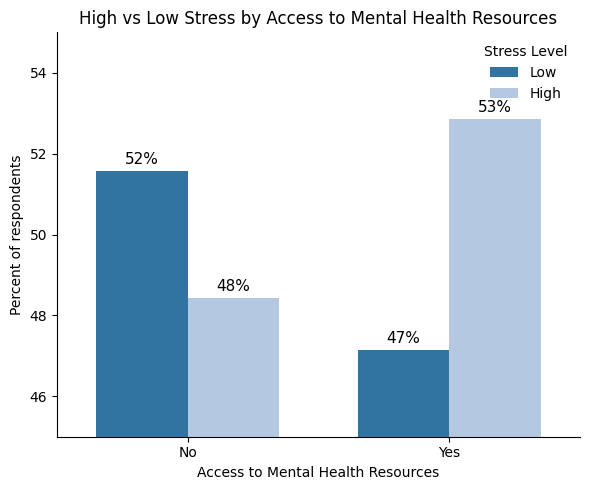

In [23]:
plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=share,
    x="Access_to_Mental_Health_Resources",
    y="Percent",
    hue="Stress_Level",
    palette=["#1f77b4", "#aec7e8"],
    width=0.7
)

plt.title("High vs Low Stress by Access to Mental Health Resources")
plt.xlabel("Access to Mental Health Resources")
plt.ylabel("Percent of respondents")

# 🔍 Zoom in on 45–55% range to emphasize the difference
plt.ylim(45, 55)

# Add clear labels
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", label_type="edge", fontsize=11, padding=3)

# Style tweaks
sns.despine()
plt.legend(title="Stress Level", loc="upper right", frameon=False)
plt.tight_layout()
plt.show()


From this we can say people have support for mental health resource have higher stress, its doesn't make sense

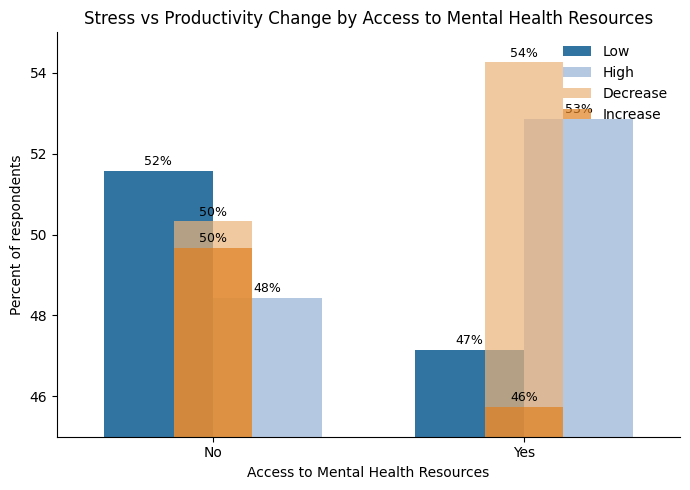

In [24]:

# --- 1️⃣ Filter High/Low stress only ---
subset = df[df["Stress_Level"].isin(["High","Low"])].copy()

# --- 2️⃣ Compute stress percentages by access ---
stress_share = (
    subset.groupby("Access_to_Mental_Health_Resources")["Stress_Level"]
          .value_counts(normalize=True)
          .rename("Percent")
          .reset_index()
)
stress_share["Percent"] *= 100

# --- 3️⃣ Compute productivity change (Increase vs Decrease) by access ---
prod_share = (
    df[df["Productivity_Change"].isin(["Increase","Decrease"])]
      .groupby("Access_to_Mental_Health_Resources")["Productivity_Change"]
      .value_counts(normalize=True)
      .rename("Prod_Percent")
      .reset_index()
)
prod_share["Prod_Percent"] *= 100

# --- 4️⃣ Plot combined chart ---
plt.figure(figsize=(7,5))
ax = sns.barplot(
    data=stress_share,
    x="Access_to_Mental_Health_Resources",
    y="Percent",
    hue="Stress_Level",
    palette=["#1f77b4", "#aec7e8"],
    width=0.7
)

# Overlay orange bars (narrower) for productivity
sns.barplot(
    data=prod_share,
    x="Access_to_Mental_Health_Resources",
    y="Prod_Percent",
    hue="Productivity_Change",
    palette=["#ffb366", "#ff8000"],
    width=0.25,
    alpha=0.7,
    dodge=False,   # ensures they stack centered, not side by side
    ax=ax
)

plt.title("Stress vs Productivity Change by Access to Mental Health Resources")
plt.xlabel("Access to Mental Health Resources")
plt.ylabel("Percent of respondents")
plt.ylim(45, 55)

# Add % labels
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", fontsize=9, padding=2)

plt.legend(title="", loc="upper right", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()


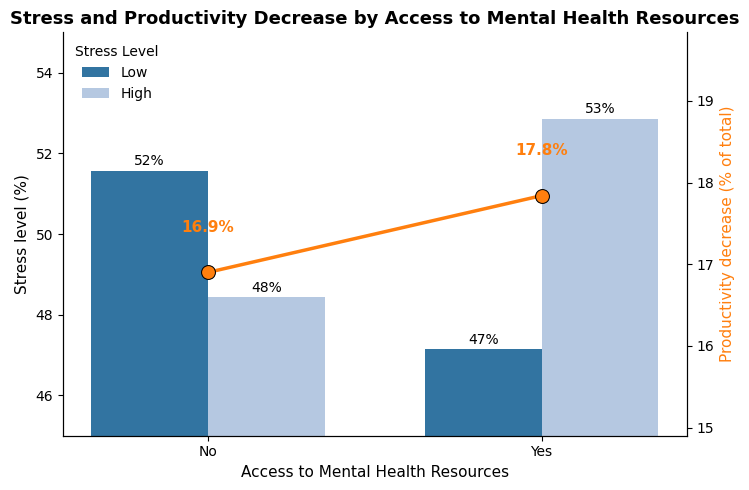

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Filter High/Low stress ---
subset = df[df["Stress_Level"].isin(["High", "Low"])].copy()

# --- Stress percentages (within group) ---
stress_share = (
    subset.groupby("Access_to_Mental_Health_Resources")["Stress_Level"]
          .value_counts(normalize=True)
          .rename("Percent")
          .reset_index()
)
stress_share["Percent"] *= 100

# --- Productivity Decrease as % of ALL respondents ---
total_n = len(df)
prod_share = (
    df[df["Productivity_Change"] == "Decrease"]
      .groupby("Access_to_Mental_Health_Resources")
      .size()
      .reset_index(name="Count")
)
prod_share["Prod_Percent"] = (prod_share["Count"] / total_n) * 100

# --- Plot setup ---
fig, ax1 = plt.subplots(figsize=(7.5, 5))

# Bars: Stress (High vs Low)
sns.barplot(
    data=stress_share,
    x="Access_to_Mental_Health_Resources",
    y="Percent",
    hue="Stress_Level",
    palette=["#1f77b4", "#aec7e8"],
    width=0.7,
    ax=ax1
)

ax1.set_ylabel("Stress level (%)", fontsize=11)
ax1.set_xlabel("Access to Mental Health Resources", fontsize=11)
ax1.set_ylim(45, 55)
ax1.set_title("Stress and Productivity Decrease by Access to Mental Health Resources", fontsize=13, weight='bold')

# Bar labels
for c in ax1.containers:
    ax1.bar_label(c, fmt="%.0f%%", fontsize=10, padding=2)

# --- Line for productivity decrease ---
ax2 = ax1.twinx()

sns.lineplot(
    data=prod_share,
    x="Access_to_Mental_Health_Resources",
    y="Prod_Percent",
    color="#ff7f0e",
    linewidth=2.5,
    marker="o",
    markersize=10,
    markeredgecolor="black",
    ax=ax2
)

# Label points directly on line
for i, row in prod_share.iterrows():
    ax2.text(
        row["Access_to_Mental_Health_Resources"],
        row["Prod_Percent"] + 0.5,
        f"{row['Prod_Percent']:.1f}%",
        color="#ff7f0e",
        fontsize=11,
        ha="center",
        weight="bold"
    )

ax2.set_ylim(prod_share["Prod_Percent"].min() - 2, prod_share["Prod_Percent"].max() + 2)
ax2.set_ylabel("Productivity decrease (% of total)", fontsize=11, color="#ff7f0e")

# Make it clean
ax1.legend(title="Stress Level", loc="upper left", frameon=False)
sns.despine(right=False)
plt.tight_layout()
plt.show()


It doesn't make sense, people having access to mental health have higher number of people feel decrease in productivity

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_8722/2490285396.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


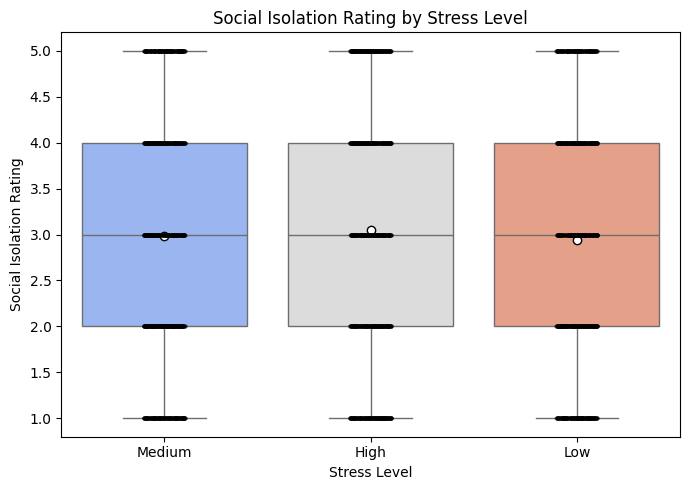

In [26]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="Stress_Level",
    y="Social_Isolation_Rating",
    palette="coolwarm",
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
)
sns.stripplot(
    data=df,
    x="Stress_Level",
    y="Social_Isolation_Rating",
    color="black",
    size=3,
    alpha=0.3
)
plt.title("Social Isolation Rating by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Social Isolation Rating")
plt.tight_layout()
plt.show()


They are totally equal distribution

### 2.2. Categorical ↔ Numeric (box/violin + ANOVA/Kruskal)

Finding realtionship

In [27]:
from scipy.stats import f_oneway, kruskal

def scan_cat_num_relationships(df, alpha=0.05):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    results = []

    for cat in cat_cols:
        for num in num_cols:
            groups = [g[num].dropna().values for _, g in df.groupby(cat)]
            if len(groups) > 1:  # skip if only one category
                # ANOVA (parametric)
                try:
                    fstat, p_anova = f_oneway(*groups)
                except:
                    p_anova = None
                # Kruskal-Wallis (nonparametric)
                try:
                    hstat, p_kruskal = kruskal(*groups)
                except:
                    p_kruskal = None
                
                results.append((cat, num, p_anova, p_kruskal))
    
    results_df = pd.DataFrame(results, columns=["Categorical", "Numeric", "ANOVA_p", "Kruskal_p"])
    
    # Add significance flags
    results_df["ANOVA_Significant"] = results_df["ANOVA_p"] < alpha
    results_df["Kruskal_Significant"] = results_df["Kruskal_p"] < alpha
    
    return results_df.sort_values("Kruskal_p")

# Run it
cat_num_results = scan_cat_num_relationships(df)
print(cat_num_results.head(10))  # show top 10 strongest

                          Categorical                     Numeric   ANOVA_p  Kruskal_p  ANOVA_Significant  \
24                      Work_Location  Number_of_Virtual_Meetings  0.007912   0.008139               True   
5                              Gender     Social_Isolation_Rating  0.017928   0.017263               True   
43  Access_to_Mental_Health_Resources         Years_of_Experience  0.023293   0.022648               True   
8                            Job_Role         Years_of_Experience  0.070227   0.072924              False   
33                       Stress_Level     Social_Isolation_Rating  0.082189   0.081565              False   
18                           Industry    Work_Life_Balance_Rating  0.082995   0.082393              False   
32                       Stress_Level    Work_Life_Balance_Rating  0.089065   0.088728              False   
60      Satisfaction_with_Remote_Work    Work_Life_Balance_Rating  0.112027   0.110601              False   
2                  

Heatmap

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def plot_single_pvalue_heatmap(res, p_col="Kruskal_p", alpha=0.05, title=None):
    """
    Elegant rectangular p-value heatmap (Categorical × Numeric).
    - Soft blue palette
    - Significant p-values (p < alpha): bold and slightly larger
    """

    if res is None or len(res) == 0:
        print("No cat–num relationships to plot.")
        return

    # Pivot to table form
    heatmap_data = res.pivot(index="Categorical",
                             columns="Numeric",
                             values=p_col)

    # Soft blue gradient (no harsh yellow)
    cmap = LinearSegmentedColormap.from_list(
        "soft_blue", ["#f8f9fa", "#bcd2e8", "#4f83cc"]
    )

    plt.figure(figsize=(1.2*len(heatmap_data.columns),
                        0.8*len(heatmap_data.index)))

    ax = sns.heatmap(
        heatmap_data,
        cmap=cmap,
        vmin=0, vmax=1,
        annot=False,
        linewidths=0.4,
        linecolor="white",
        cbar_kws={"label": "p-value"}
    )

    # --- Annotate with dynamic font size for significant p-values ---
    for i, row in enumerate(heatmap_data.index):
        for j, col in enumerate(heatmap_data.columns):
            val = heatmap_data.loc[row, col]
            if pd.isna(val):
                continue

            is_sig = val < alpha
            ax.text(
                j + 0.5, i + 0.5, f"{val:.3f}",
                ha="center", va="center",
                fontsize=9 if is_sig else 7,      # bigger if significant
                fontweight="bold" if is_sig else "normal",
                color="black"
            )

    ax.set_title(title or f"{p_col.replace('_',' ').title()} Heatmap (Categorical × Numeric)",
                 fontsize=13, weight="bold", pad=12)
    plt.xlabel("Numeric Variables", fontsize=11)
    plt.ylabel("Categorical Variables", fontsize=11)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


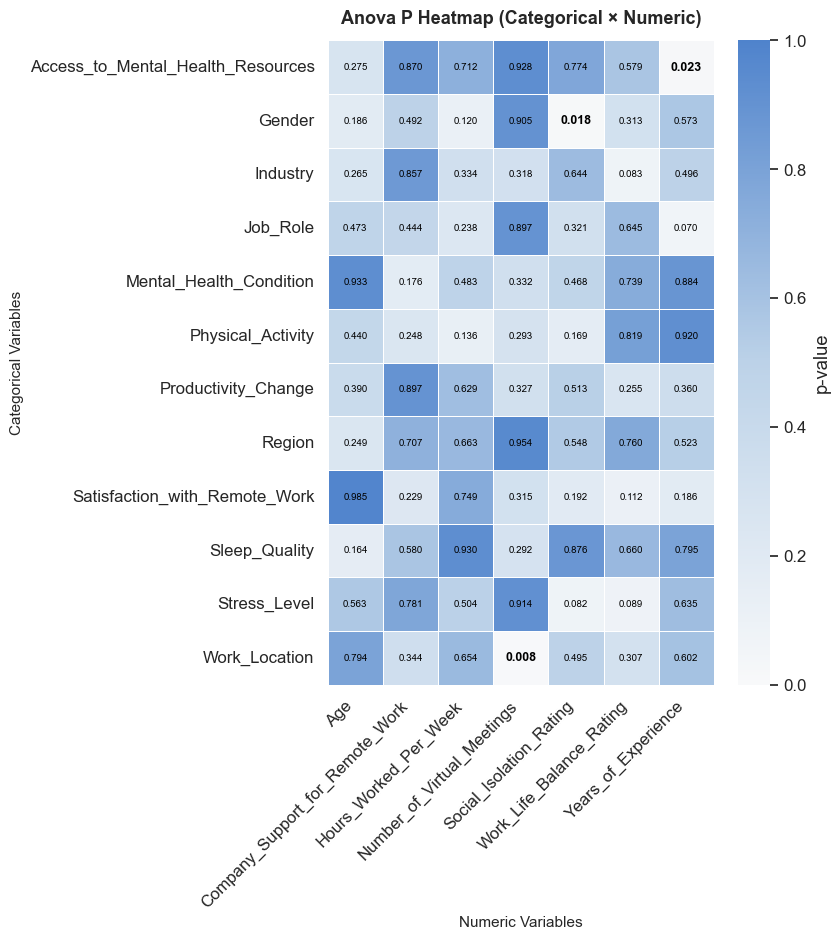

In [55]:
plot_single_pvalue_heatmap(cat_num_results, p_col="ANOVA_p")

Number of meeting have connection to work location, i guess remote worker need to have more meeting. Will look at them deeper

#### Work Location and Number of virtual meeting

boxplot + swarm/strip overlay

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_8722/3260984324.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 64.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 65.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/huongle/Documents/GitHub/Mind_At_Work_Website/.venv/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 63.8% of the points cannot be placed; you ma

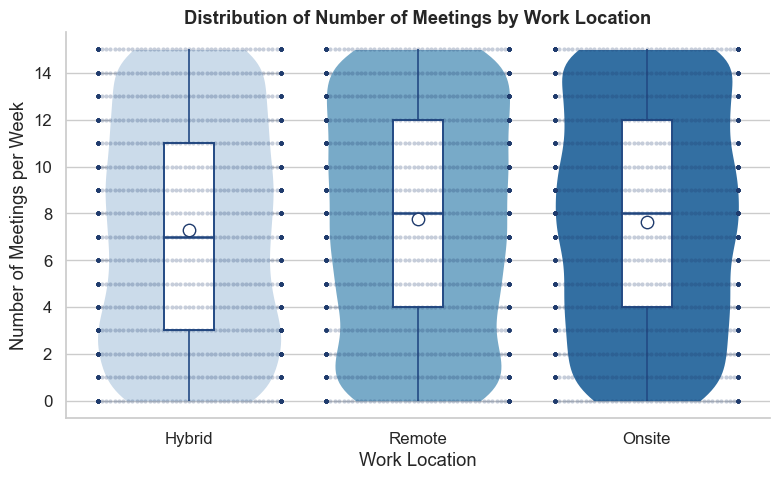

In [28]:


# ensure numeric & no nulls
df = df.copy()
df["Number_of_Virtual_Meetings"] = pd.to_numeric(df["Number_of_Virtual_Meetings"], errors="coerce")
df = df.dropna(subset=["Work_Location", "Number_of_Virtual_Meetings"])

# aesthetic theme
sns.set_theme(style="whitegrid", font_scale=1.1)
palette = sns.color_palette("Blues", 3)  # light→dark blues

plt.figure(figsize=(8,5))
ax = sns.violinplot(
    data=df,
    x="Work_Location",
    y="Number_of_Virtual_Meetings",
    palette=palette,
    inner=None,         # no inner bars; we’ll add a box on top
    cut=0,
    linewidth=0
)

# crisp white box for IQR + median
sns.boxplot(
    data=df,
    x="Work_Location",
    y="Number_of_Virtual_Meetings",
    width=0.22,
    showcaps=False,
    boxprops={"facecolor":"white", "edgecolor":"#234A84", "linewidth":1.4},
    whiskerprops={"color":"#234A84", "linewidth":1.2},
    medianprops={"color":"#234A84", "linewidth":1.8},
    showfliers=False
)

# subtle swarm (few jittered points, semi-transparent)
sns.swarmplot(
    data=df,
    x="Work_Location",
    y="Number_of_Virtual_Meetings",
    color="#1f3b6d",
    alpha=0.25,
    size=3
)

# optional: show mean as a white dot with dark edge
group_means = df.groupby("Work_Location")["Number_of_Virtual_Meetings"].mean()
xticks = ax.get_xticks()
plt.scatter(xticks, group_means.values, s=80, c="white", edgecolors="#1f3b6d", zorder=5)

ax.set_title("Distribution of Number of Meetings by Work Location", weight="bold")
ax.set_xlabel("Work Location")
ax.set_ylabel("Number of Meetings per Week")
sns.despine()
plt.tight_layout()
plt.show()


Remote employees tend to have slightly more meetings per week than hybrid or onsite workers. Hybrid staff show the most balanced distribution, while onsite teams rely less on frequent meetings.

#### Stress_Level → Social_Isolation_Rating

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_8722/2490285396.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


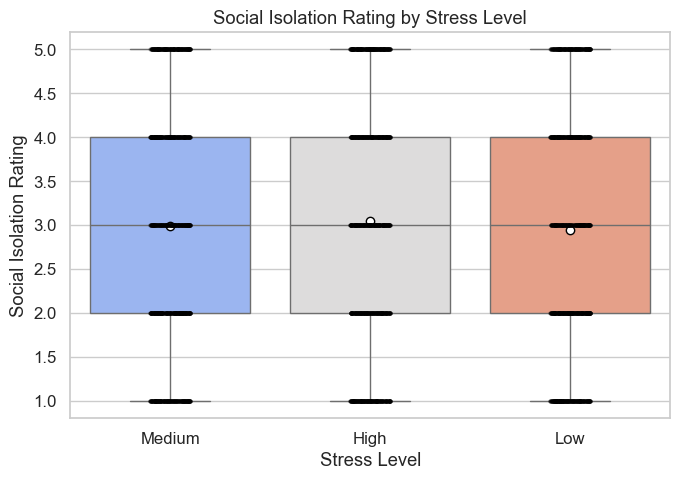

In [29]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x="Stress_Level",
    y="Social_Isolation_Rating",
    palette="coolwarm",
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black"}
)
sns.stripplot(
    data=df,
    x="Stress_Level",
    y="Social_Isolation_Rating",
    color="black",
    size=3,
    alpha=0.3
)
plt.title("Social Isolation Rating by Stress Level")
plt.xlabel("Stress Level")
plt.ylabel("Social Isolation Rating")
plt.tight_layout()
plt.show()


social isolation levels remain fairly similar across stress groups

### Social Isolation and Work–Life Balance by Work Location

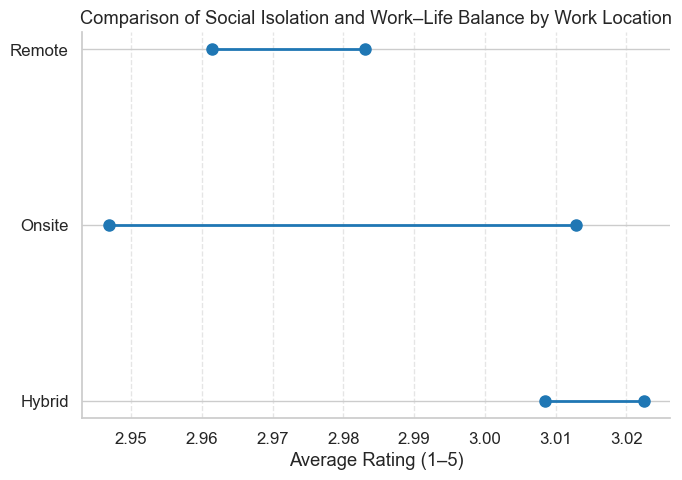

In [30]:
from matplotlib import pyplot as plt

group_means = df.groupby("Work_Location")[["Social_Isolation_Rating","Work_Life_Balance_Rating"]].mean()

plt.figure(figsize=(7,5))
for i, (loc, row) in enumerate(group_means.iterrows()):
    plt.plot([row["Social_Isolation_Rating"], row["Work_Life_Balance_Rating"]],
             [i, i], 'o-', color="#1f77b4", lw=2, markersize=8)
plt.yticks(range(len(group_means)), group_means.index)
plt.xlabel("Average Rating (1–5)")
plt.title("Comparison of Social Isolation and Work–Life Balance by Work Location")
plt.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()


- The left dot represents Social Isolation (lower is better).
- The right dot represents Work–Life Balance (higher is better).
- The length of the line shows the gap between the two metrics.

Remote workers score slightly lower on work–life balance than onsite and hybrid staff.
Hybrid employees have marginally higher overall well-being (both isolation and balance around 3.0+).

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_8722/2129662626.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Work_Location", y="Social_Isolation_Rating", palette="Blues", ax=axes[0])
/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_8722/2129662626.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Work_Location", y="Work_Life_Balance_Rating", palette="Greens", ax=axes[1])


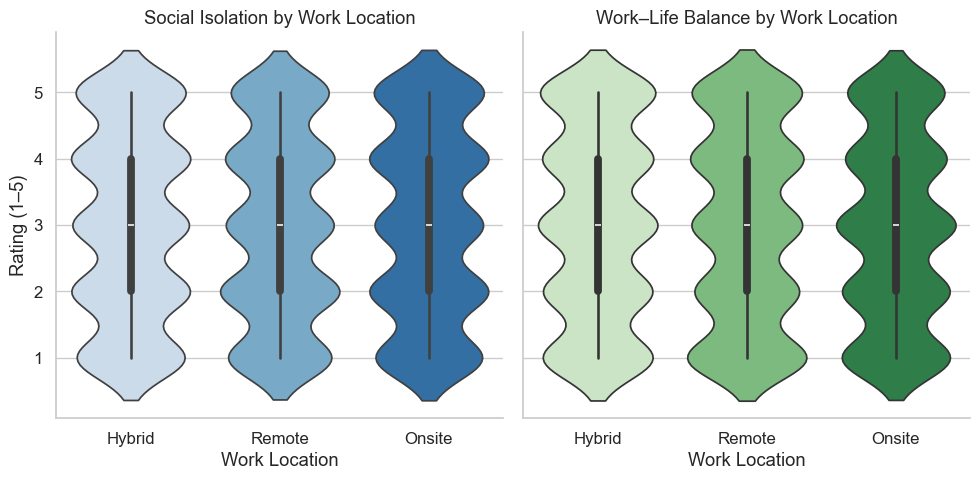

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10,5), sharey=True)

sns.violinplot(data=df, x="Work_Location", y="Social_Isolation_Rating", palette="Blues", ax=axes[0])
axes[0].set_title("Social Isolation by Work Location")

sns.violinplot(data=df, x="Work_Location", y="Work_Life_Balance_Rating", palette="Greens", ax=axes[1])
axes[1].set_title("Work–Life Balance by Work Location")

for ax in axes:
    ax.set_xlabel("Work Location")
    ax.set_ylabel("Rating (1–5)")
sns.despine()
plt.tight_layout()
plt.show()

All of it looks equally distributed

### 2.3. Numeric to Numeric 

In [32]:
from scipy.stats import pearsonr, spearmanr

def scan_num_num_relationships(df, alpha=0.05):
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    results = []

    for i in range(len(num_cols)):
        for j in range(i+1, len(num_cols)):  # avoid duplicates
            col1, col2 = num_cols[i], num_cols[j]
            x, y = df[col1].dropna(), df[col2].dropna()
            min_len = min(len(x), len(y))
            if min_len > 2:  # need data
                # Pearson (linear correlation)
                r_pearson, p_pearson = pearsonr(df[col1], df[col2])
                # Spearman (rank-based, non-linear)
                r_spearman, p_spearman = spearmanr(df[col1], df[col2])
                results.append((col1, col2, r_pearson, p_pearson, r_spearman, p_spearman))
    
    results_df = pd.DataFrame(results, columns=[
        "Var1", "Var2", "Pearson_r", "Pearson_p", "Spearman_r", "Spearman_p"
    ])
    results_df["Pearson_Significant"] = results_df["Pearson_p"] < alpha
    results_df["Spearman_Significant"] = results_df["Spearman_p"] < alpha
    return results_df.sort_values("Pearson_p")

# Run it
num_num_results = scan_num_num_relationships(df)
print(num_num_results.head(10))

                          Var1                             Var2  Pearson_r  Pearson_p  Spearman_r  Spearman_p  \
4                          Age          Social_Isolation_Rating  -0.024992   0.077225   -0.025038    0.076681   
5                          Age  Company_Support_for_Remote_Work   0.023673   0.094185    0.023641    0.094627   
7          Years_of_Experience       Number_of_Virtual_Meetings   0.019043   0.178188    0.018940    0.180551   
6          Years_of_Experience            Hours_Worked_Per_Week  -0.018537   0.190015   -0.018678    0.186663   
3                          Age         Work_Life_Balance_Rating   0.017697   0.210867    0.017235    0.223045   
20     Social_Isolation_Rating  Company_Support_for_Remote_Work   0.017659   0.211858    0.017653    0.212024   
19    Work_Life_Balance_Rating  Company_Support_for_Remote_Work  -0.012913   0.361303   -0.013084    0.354990   
15  Number_of_Virtual_Meetings         Work_Life_Balance_Rating   0.007285   0.606528    0.00720

=> Numeric features in dataset don’t strongly explain each other — they are relatively independent.

#### Q7. How stress levels (High, Medium, Low) differ across job roles, split by work location (Remote/Hybrid/Onsite)?

<Figure size 1000x600 with 0 Axes>

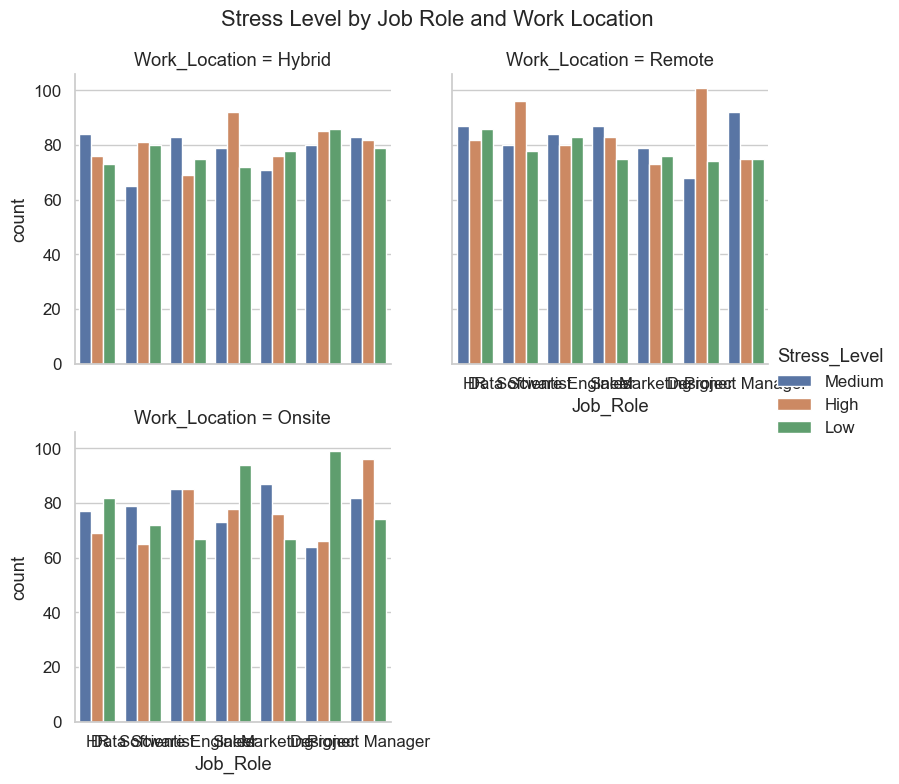

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.catplot(
    data=df, x="Job_Role", hue="Stress_Level", col="Work_Location",
    kind="count", col_wrap=2, height=4
)
plt.subplots_adjust(top=0.9)
plt.suptitle("Stress Level by Job Role and Work Location")
plt.show()

#### Q8. Physical Activity vs Stress Level

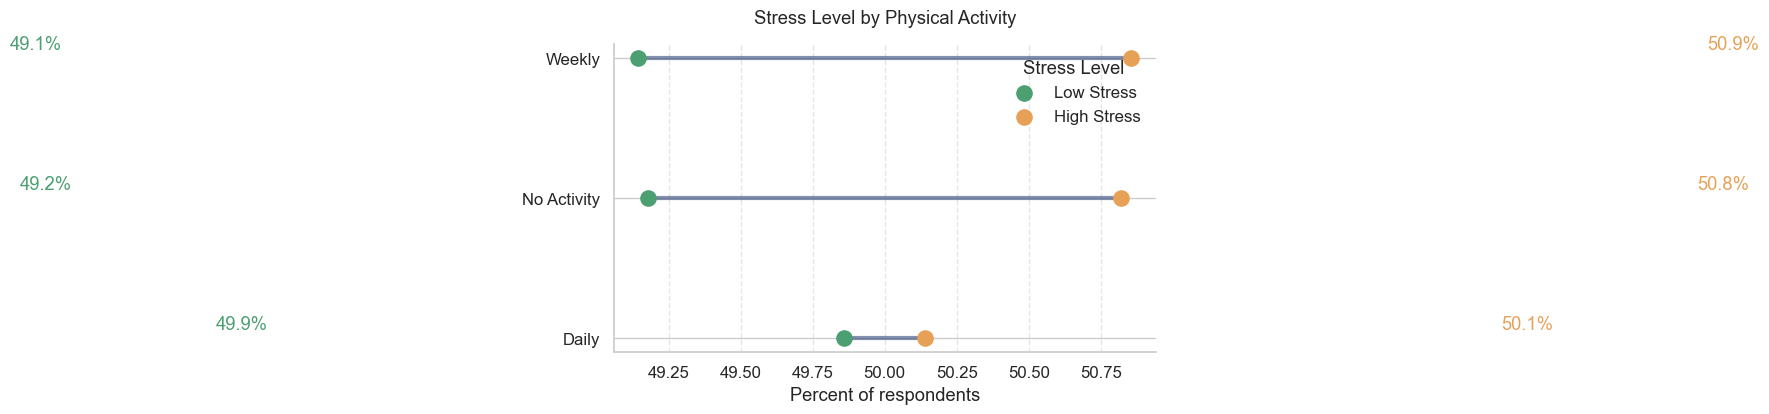

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- prepare data ---
subset = df[df['Stress_Level'].isin(['High', 'Low'])]
group_data = (
    subset.groupby('Physical_Activity')['Stress_Level']
    .value_counts(normalize=True)
    .unstack()
    .fillna(0) * 100
)
group_data = group_data[['Low', 'High']].reset_index()

# --- plot dumbbell ---
plt.figure(figsize=(7, 4))
for i, row in group_data.iterrows():
    plt.plot([row['Low'], row['High']], [i, i], color='#31487A', linewidth=3, alpha=0.6)
    plt.scatter(row['Low'], i, color='#4C9F70', s=120, label='Low Stress' if i == 0 else "", zorder=3)
    plt.scatter(row['High'], i, color='#E6A157', s=120, label='High Stress' if i == 0 else "", zorder=3)

# --- labels and design ---
plt.yticks(range(len(group_data)), group_data['Physical_Activity'])
plt.xlabel("Percent of respondents")
plt.title("Stress Level by Physical Activity", pad=15)
plt.legend(title="Stress Level", loc="upper right", frameon=False)
plt.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine()

# --- annotate percentages ---
for i, row in group_data.iterrows():
    plt.text(row['Low'] - 2, i + 0.1, f"{row['Low']:.1f}%", color='#4C9F70', ha='right', va='center')
    plt.text(row['High'] + 2, i + 0.1, f"{row['High']:.1f}%", color='#E6A157', ha='left', va='center')

plt.show()


People having physical activity daily have less stress

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_8722/2714498991.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  d.pivot_table(index="Work_Hour_Group", columns="Sleep_Quality", aggfunc="size", fill_value=0)


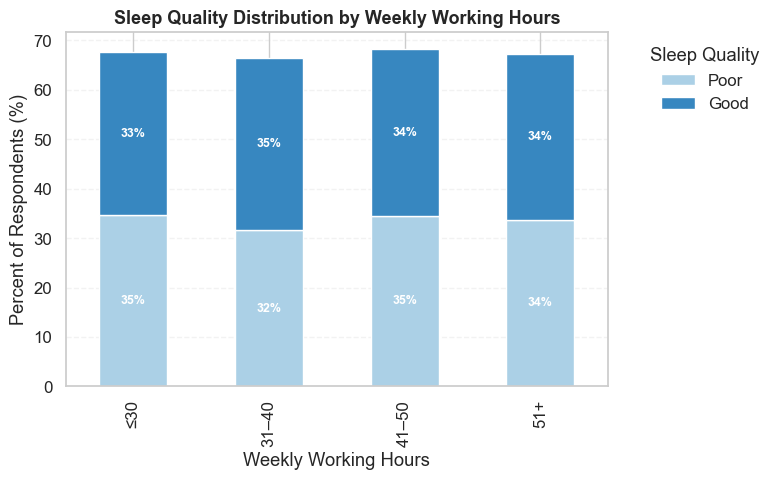

In [35]:


# --- Prepare data ---
d = df.dropna(subset=["Hours_Worked_Per_Week", "Sleep_Quality"]).copy()

# Bin working hours
bins = [0, 30, 40, 50, 100]
labels = ["≤30", "31–40", "41–50", "51+"]
d["Work_Hour_Group"] = pd.cut(d["Hours_Worked_Per_Week"], bins=bins, labels=labels, include_lowest=True)

# Ensure Sleep_Quality is string (avoid category dtype issues)
d["Sleep_Quality"] = d["Sleep_Quality"].astype(str)

# Build pivot table (counts → percentages)
pivot = (
    d.pivot_table(index="Work_Hour_Group", columns="Sleep_Quality", aggfunc="size", fill_value=0)
    .astype(float)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

# Sort columns logically if possible
ordered_cols = ["Very Poor", "Poor", "Fair", "Good", "Excellent"]
existing_cols = [c for c in ordered_cols if c in pivot.columns]
pivot = pivot[existing_cols] if existing_cols else pivot

# --- Plot ---
colors = sns.color_palette("Blues", n_colors=len(pivot.columns))
ax = pivot.plot(kind="bar", stacked=True, figsize=(8,5), color=colors, edgecolor="white")

plt.title("Sleep Quality Distribution by Weekly Working Hours", fontsize=13, weight="bold")
plt.xlabel("Weekly Working Hours")
plt.ylabel("Percent of Respondents (%)")
plt.legend(title="Sleep Quality", bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False)
plt.grid(alpha=0.25, linestyle="--", axis="y")
plt.tight_layout()

# Add percentage labels on each segment
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", label_type="center", color="white", fontsize=9, weight="bold")

plt.show()


The gaps doesn't look big to say connection between hours working and sleep quality 